# EverPeak-Analysis.

### Este proyecto realiza un análisis integral de datos (Business Intelligence) sobre el conjunto de datos de operaciones comerciales de EverPeak. El objetivo principal es auditar la calidad de la información, entender el comportamiento del consumidor y evaluar la eficiencia operativa de los puntos de venta para respaldar la toma de decisiones estratégicas.

In [3]:
# Nombre de dónde estudio
plataforma_educativa = "TripleTen"
print(plataforma_educativa)

TripleTen


In [16]:
# Nombre Estudiente.
nombre = "Joel Serrato Guzmán"

#Pais
pais = "México"

# curso que estoy estudiando
mi_curso = '"Analisis de Datos"'

# Sprint en el que estoy
mi_sprint = 'No. 7'


In [18]:
# imprimir información curso
print("Nombre Alumno:", nombre)
print("Pais:", pais)
print('Estoy estudiando el curso de', mi_curso, 'en', plataforma_educativa)
print('Actualmente curso el sprint', mi_sprint)


Nombre Alumno: Joel Serrato Guzmán
Pais: México
Estoy estudiando el curso de "Analisis de Datos" en TripleTen
Actualmente curso el sprint No. 7


In [21]:
#Importar Pandas y cargar datos
import pandas as pd
df = pd.read_csv("/datasets/everpeak_retail.csv")
df. head()

,order_id,order_date,customer_id,product_category,price,quantity,order_value,payment_method,city,state,customer_age,quantity_invalid_flag,age_invalid_flag,state_missing_flag
0,1,2024-02-02,2616,Sports,269,50,13385,credit_card,New York,NY,66,0,0,0
1,2,2024-10-10,1736,Grocery,66,10,660,debit_card,Los Angeles,CA,24,1,0,0
2,3,2024-08-27,2543,Sports,267,19,5073,credit_card,Chicago,IL,23,1,0,0
3,4,2024-06-09,2252,Toys,114,125,14290,credit_card,New York,NY,70,0,0,0
4,5,2024-06-07,1583,Fashion,729,16,11754,credit_card,Houston,TX,75,0,0,0


##Conteo de valores faltantes por columna
🎯Objetivo: Contar cuántos valores faltantes tiene cada variable de segmentación y ubicación, usando sumas, no porcentajes.
Instrucciones:
1.Calcula cuántos valores faltantes tienen las columnas payment_method, city y state.
2.Crea una variable distinta por columna.
3.Usa print() para mostrar el resultado de cada variable en una línea separada.

In [22]:
import pandas as pd
df = pd.read_csv("/datasets/everpeak_retail.csv")
payment_missing = df["payment_method"].isna().sum()
city_missing = df["city"].isna().sum()
state_missing = df["state"].isna().sum() 
print("payment_method missing:", payment_missing)
print("city missing:", city_missing)
print("state missing:", state_missing)

payment_method missing: 0
city missing: 100
state missing: 100


Fechas sospechosas y montos extremos
🎯Objetivo: Medir cuántos registros tienen fechas sospechosas y montos anormalmente altos.
Instrucciones:
1.Convierte la columna order_date a formato fecha, tratando los errores como valores faltantes.
2.Usando .sum(), calcula cuántos registros tienen como año 2026 en order_date (un año no transcurrido al guardar los datos).
3.Usando .sum(), calcula cuántos registros tienen order_date vacía después de la conversión.
4.Imprime cada conteo por separado con print().

In [23]:
import pandas as pd
df = pd.read_csv("/datasets/everpeak_retail.csv")
df["order_date"] = pd.to_datetime(df["order_date"],errors="coerce") 
invalid_year_2026_count = df["order_date"].dt.year 
missing_order_date_count = (df["order_date"].dt.year == 2026).isna().sum()
print("order_date año 2026:", invalid_year_2026_count)
print("order_date missing:", missing_order_date_count)

order_date año 2026: 0       2024.0
1       2024.0
2       2024.0
3       2024.0
4       2024.0
         ...  
5003       NaN
5004       NaN
5005       NaN
5006       NaN
5007       NaN
Name: order_date, Length: 5008, dtype: float64
order_date missing: 0


Cardinalidad en columnas de cliente
🎯Objetivo: Calcular la cardinalidad de columnas clave para entender si son IDs, categorías o variables poco útiles.
Instrucciones:
1.Calcula cuántos valores únicos tiene customer_id.
2.Calcula cuántos valores únicos tiene customer_segment.
3.Calcula cuántos valores únicos tienen city y state (cada una por separado).
4.Imprime cada resultado con print(), mostrando el nombre de la columna y su número de valores únicos.

In [24]:
import pandas as pd
df = pd.read_csv("/datasets/everpeak_retail.csv")
customer_id_unicos = df["customer_id"].nunique()
payment_unicos = df["payment_method"].nunique()
city_unicos = df["city"].nunique()
state_unicos = df["state"].nunique() 
print("customer_id nunique:", customer_id_unicos)
print("payment_method nunique:", payment_unicos)
print("city nunique:", city_unicos)
print("state nunique:", state_unicos)

customer_id nunique: 1829
payment_method nunique: 4
city nunique: 10
state nunique: 9


El primer análisis es detectar si los valores faltantes de customer_age se concentran en ciertos grupos, como ciudades o categorías de producto.

In [25]:
df['customer_age'].isna().groupby(df['city']).mean().sort_values(ascending=False)

city
New York         0.048290
Boston           0.037975
San Francisco    0.032051
Los Angeles      0.031311
Seattle          0.031189
Miami            0.030181
Phoenix          0.024440
Houston          0.023346
Chicago          0.020747
Denver           0.019523
Name: customer_age, dtype: float64

En este caso, no hay una ciudad con valores vacíos especialmente alta. Parece que no hay ninguna relación entre los valores faltantes y a ciudad. 

In [ ]:
Sigamos con la agrupación por categoría de producto.

In [26]:
df['customer_age'].isna().groupby(df['product_category']).mean()

product_category
?              0.000000
Beauty         0.027739
Electronics    0.031250
Fashion        0.025676
Grocery        0.027778
Home           0.029455
Sports         0.049716
Toys           0.019471
Name: customer_age, dtype: float64

Primero creamos una bandera, es decir una columna nueva que indique cuáles filas tienen edad faltante y cuales no. 

In [27]:
df['edad_vacia'] = df['customer_age'].isna().astype(int)
df.head()

,order_id,order_date,customer_id,product_category,price,quantity,order_value,payment_method,city,state,customer_age,edad_vacia
0,1,2024-02-02,2616,Sports,269,50,13385,credit_card,New York,NY,66.0,0
1,2,2024-10-10,1736,Grocery,66,0,660,debit_card,Los Angeles,CA,24.0,0
2,3,2024-08-27,2543,Sports,267,0,5073,credit_card,Chicago,IL,23.0,0
3,4,2024-06-09,2252,Toys,114,125,14290,credit_card,New York,NY,70.0,0
4,5,2024-06-07,1583,Fashion,729,16,11754,credit_card,Houston,TX,75.0,0


Como puedes ver añadimos una nueva columna que nos indica si la edad falta en cada fila. 0 indica “no” y 1 indica “si”. 

Ahora comparamos el comportamiento de compra entre clientes con edad y clientes sin edad, usando order_value.”

In [28]:
df.groupby("edad_vacia")["order_value"].describe()

,count,mean,std,min,25%,50%,75%,max
edad_vacia,,,,,,,,
0,4858.0,10108.75916,12406.435518,12.0,3158.25,10411.5,13163.0,303824.0
1,150.0,8866.96000,12102.064531,37.0,1993.75,5023.0,11405.5,78964.0


En conclusión, las edades vacías parecen indicar un caso de MCAR. Faltante completamente al azar. 

Si los valores faltantes en customer_age son MCAR (Missing Completely At Random) y representan solo ~3%, entonces la mejor práctica es elegir un método simple, estable y que no introduzca sesgos artificiales.

In [34]:
#Primero calculamos la mediana de customer_age.
median_age = df['customer_age'].median()

#Luego usamos esa mediana para rellenar los valores faltantes.
df['customer_age'] = df['customer_age'].fillna(median_age)

#Y por último, validamos que la imputación funcionó correctamente.
df['customer_age'].isna().sum()

#¿Cómo limpiar quantity <= 0 paso a paso?
#Los valores inválidos usualmente NO se clasifican como MCAR/MAR/MNAR porque no son ausencias, sino errores.


0

In [38]:
import numpy as np
# Marcar como NaN los valores inválidos de quantity
df.loc[df['quantity'] <= 0, 'quantity'] = np.nan
# Comprobamos si la cantidad calculada (order_value / price) coincide con la columna quantity
df['calculated_quantity'] = df['order_value'] / df['price']

# Verificamos las primeras filas donde la cantidad es cero o inválida
df[['order_value', 'price', 'quantity', 'calculated_quantity']].head()

#Desglosemos este código parte por parte.
#Crear una columna calculada
df['calculated_quantity'] = df['order_value'] / df['price']

#Comparar valores lado a lado
df[['order_value', 'price', 'quantity', 'calculated_quantity']].head()

,order_value,price,quantity,calculated_quantity
0,13385,269,50.0,49.758364
1,660,66,NaN,10.000000
2,5073,267,NaN,19.000000
3,14290,114,125.0,125.350877
4,11754,729,16.0,16.123457


In [39]:
# Imputar los valores faltantes con el cálculo de order_value / price
df['quantity'] = (df['order_value'] / df['price']).round()


In [40]:
#Rellenar solo los valores faltantes
df['quantity'] = df['quantity'].fillna(df['order_value'] / df['price'])

In [ ]:
#Caso 2: Buscar sentinels en múltiples columnas (EverPeak)
#Este es un problema clásico: EverPeak usa -999 como valor inválido en varias columnas numéricas. 

In [41]:
import pandas as pd
df = pd.read_csv("/datasets/everpeak_retail.csv")
columnas = ["customer_age", "quantity", "order_value"]
sentinel = -999
for col in columnas:
    print(col,"→", df[col].isin([-999]).sum())

customer_age → 25
quantity → 0
order_value → 0


In [ ]:
#Caso 3: Iterar sobre columnas para aplicar funciones personalizadas

In [44]:
columnas_texto = ["city", "state", "product_category"]
for col in columnas_texto:
    df[col] = df[col].str.strip().str.lower()

Medidas Estadísticas en Columnas Numéricas

In [46]:
df['order_value'].mean()
df['order_value'].median()
df['order_value'].std()
df['order_value'].min(), df['order_value'].max()
df['order_value'].count()

5008

In [51]:
#Primero calculemos la media y la mediana. 
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('/datasets/everpeak_clean.csv')
mean_price = df['price'].mean()
median_price = df['price'].median()
print("Promedio:", mean_price)
print("Mediana:", median_price)

Promedio: 756.3874
Mediana: 457.0


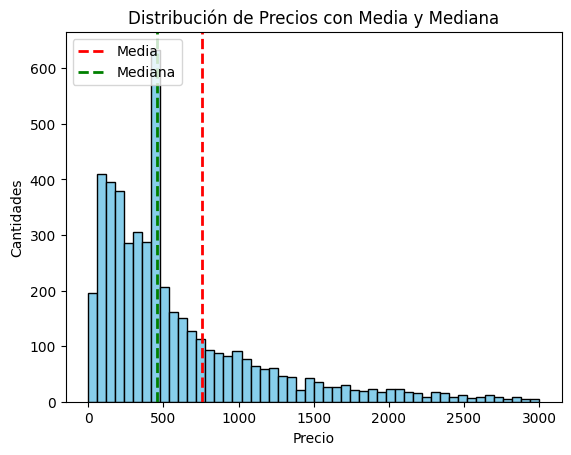

In [54]:
# Graficar histograma
plt.hist(df['price'], bins=50, color='skyblue', edgecolor='black', range=(0,3000))
# Agregar líneas de media y mediana
plt.axvline(mean_price, color='red', linestyle='dashed', linewidth=2, label='Media')
plt.axvline(median_price, color='green', linestyle='dashed', linewidth=2, label='Mediana')
# Títulos y etiquetas
plt.title('Distribución de Precios con Media y Mediana')
plt.xlabel('Precio')
plt.ylabel('Cantidades')
plt.legend(loc='upper left')
plt.show()

Responder preguntas clave del negocio:
¿Cuánto paga típicamente un cliente?
¿Qué edad tiene un cliente promedio?
¿Qué tan variable es el precio de los productos?
¿La cantidad comprada suele ser estable o dispersa?


In [55]:
import pandas as pd
df = pd.read_csv('/datasets/everpeak_clean.csv')
#aplicamos describe a columnas numéricas
print(df[['order_value', 'customer_age', 'price', 'quantity']].describe())

         order_value  customer_age         price     quantity
count    5000.000000   5000.000000   5000.000000  5000.000000
mean    10075.523800     49.120800    756.387400    32.359800
std     12406.603152     17.710679   1173.265182    93.403826
min        12.000000     18.000000     12.000000     1.000000
25%      3094.000000     34.000000    218.000000     7.000000
50%     10341.000000     49.000000    457.000000    14.000000
75%     13160.500000     64.000000    847.250000    23.000000
max    303824.000000     80.000000  36708.000000  2083.000000


In [56]:
#Usamos for para evitar repetir código:
columnas_numericas = ['order_value', 'customer_age', 'price', 'quantity']
for col in columnas_numericas:
# Media y mediana de cada columna
    print(col)
    print("Promedio", df[col].mean(),"- Mediana:", df[col].median())
    print()

order_value
Promedio 10075.5238 - Mediana: 10341.0

customer_age
Promedio 49.1208 - Mediana: 49.0

price
Promedio 756.3874 - Mediana: 457.0

quantity
Promedio 32.3598 - Mediana: 14.0



Estadísticas con .describe()
.describe() da panorama inicial: cantidad de datos, promedio, desviación estándar, percentiles y valores extremos.

In [57]:
import pandas as pd
df = pd.read_csv('/datasets/everpeak_clean.csv')
# columnas numéricas
print(df[['order_value', 'customer_age', 'price', 'quantity']].describe())

         order_value  customer_age         price     quantity
count    5000.000000   5000.000000   5000.000000  5000.000000
mean    10075.523800     49.120800    756.387400    32.359800
std     12406.603152     17.710679   1173.265182    93.403826
min        12.000000     18.000000     12.000000     1.000000
25%      3094.000000     34.000000    218.000000     7.000000
50%     10341.000000     49.000000    457.000000    14.000000
75%     13160.500000     64.000000    847.250000    23.000000
max    303824.000000     80.000000  36708.000000  2083.000000


Media y mediana
Compararlas nos ayuda a detectar si el promedio representa al dato típico o si hay outliers.

In [58]:
for col in columnas_numericas:
    # Media y mediana de cada columna
    print(col)
    print("Promedio", df[col].mean(),"- Mediana:", df[col].median())
    print()

order_value
Promedio 10075.5238 - Mediana: 10341.0

customer_age
Promedio 49.1208 - Mediana: 49.0

price
Promedio 756.3874 - Mediana: 457.0

quantity
Promedio 32.3598 - Mediana: 14.0



Resumen categórico (Toys)
Objetivo: El equipo necesita entender la distribución de los métodos de pago y las ciudades asociadas a la categoría Toys, para identificar patrones dominantes, diversidad de ciudades y posibles anomalías.

In [59]:
import pandas as pd
df = pd.read_csv('/datasets/everpeak_clean.csv')
# Columnas categóricas
columnas_categoricas = ['payment_method', 'city']
# Filtra por categoría
df_toys = df[df['product_category'] == 'Toys']   
# Resumen categórico Toys
print("Resumen categórico - Toys")
print(df_toys[columnas_categoricas].describe())  

Resumen categórico - Toys
       payment_method     city
count             715      715
unique              4       11
top       credit_card  Seattle
freq              383       81


Distribución completa de ciudades con value_counts() (Sports)
Objetivo: Revisar todas las ciudades asociadas a la categoría Sports, mostrando su frecuencia absoluta y su frecuencia relativa para entender la distribución de ubicaciones dentro de esta categoría.

In [60]:
import pandas as pd
df = pd.read_csv('/datasets/everpeak_clean.csv')
# Filtra por categoría
df_sports = df[df['product_category'] == 'Sports']  
# Distribución de city
print("Frecuencia absoluta")
print(df_sports["city"].value_counts())   
print("\nFrecuencia relativa")
print(df_sports["city"].value_counts(normalize=True))    

Frecuencia absoluta
San Francisco    85
Los Angeles      84
Miami            74
New York         74
Denver           68
Seattle          67
Boston           66
Chicago          60
Houston          59
Phoenix          55
unknown          10
Name: city, dtype: int64

Frecuencia relativa
San Francisco    0.121083
Los Angeles      0.119658
Miami            0.105413
New York         0.105413
Denver           0.096866
Seattle          0.095442
Boston           0.094017
Chicago          0.085470
Houston          0.084046
Phoenix          0.078348
unknown          0.014245
Name: city, dtype: float64


In [ ]:
Agregar grafica representativa de Datos:
    

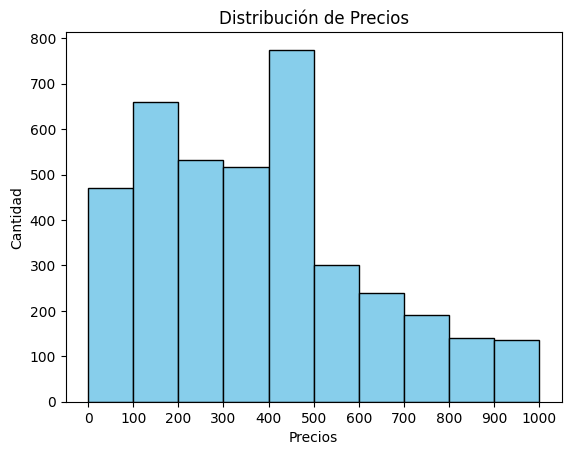

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('/datasets/everpeak_clean.csv')
# Graficar histograma
counts, bin_edges, _ = plt.hist(df['price'], bins=10, range=(0,1000), color='skyblue', edgecolor='black')     
# Mostrar las marcas de los bins en el eje X
# Escribe tu código aquí
plt.xticks(bin_edges) 
# Etiquetas y título del gráfico
plt.xlabel("Precios")
plt.ylabel("Cantidad")
plt.title("Distribución de Precios")
plt.show()

Distribución de edades de clientes
Objetivo: El equipo quiere entender la distribución de las edades de los clientes (customer_age) para segmentar mejor las estrategias de marketing.

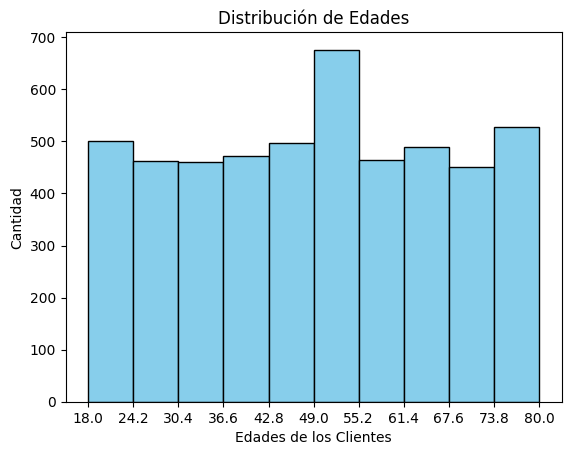

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('/datasets/everpeak_clean.csv')
# Graficar histograma
counts, bin_edges, _ = plt.hist(df["customer_age"], bins=10, color="skyblue", edgecolor="black")   # tu código aquí
# Mostrar las marcas de los bins en el eje X
# tu código aquí
plt.xticks(bin_edges) 
# Etiquetas y título del gráfico
plt.xlabel("Edades de los Clientes")
plt.ylabel("Cantidad")
plt.title("Distribución de Edades")
plt.show()

In [ ]:
Explorando distribuciones con Boxplots

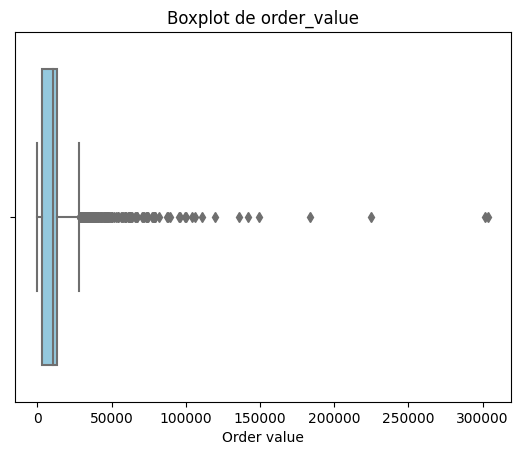

In [64]:
sns.boxplot(x=df['order_value'], color='skyblue')
plt.title('Boxplot de order_value')
plt.xlabel('Order value')
plt.show()

Explorando la dispersión de cantidades con Boxplot

Objetivo: El equipo de Inteligencia Comercial necesita analizar cómo se distribuyen las cantidades compradas (quantity) dentro de la categoría "Toys", para detectar valores extremos que podrían afectar decisiones de inventario y logística.

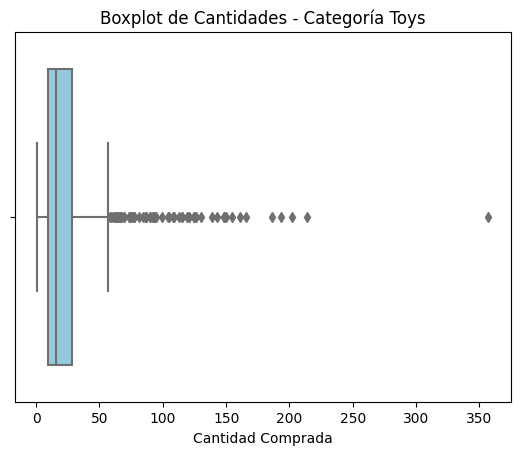

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/datasets/everpeak_clean.csv')
df_toys = df[df['product_category'] == 'Toys']   
# Graficar BoxPlot
sns.boxplot(x=df_toys['quantity'], color='skyblue')  
# Etiquetas y título del gráfico
plt.title("Boxplot de Cantidades - Categoría Toys")
plt.xlabel("Cantidad Comprada")
plt.show()

Distribución de edades de clientes

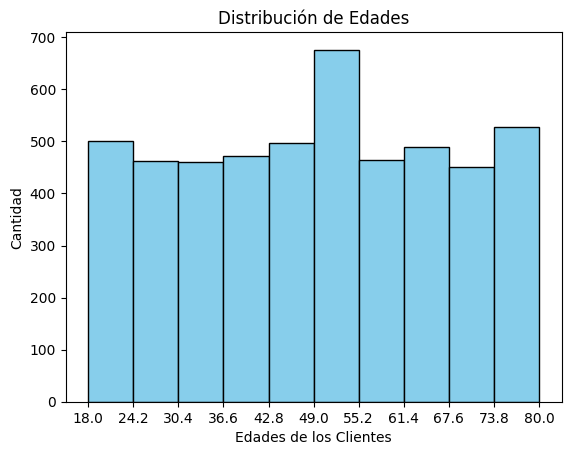

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('/datasets/everpeak_clean.csv')
# Graficar histograma
counts, bin_edges, _ = plt.hist(df['customer_age'], bins=10, color='skyblue', edgecolor='black') 
# Mostrar las marcas de los bins en el eje X
# tu código aquí
plt.xticks(bin_edges)
# Etiquetas y título del gráfico
plt.title("Distribución de Edades")  
plt.xlabel("Edades de los Clientes")   
plt.ylabel("Cantidad")
plt.show()

Boxplot del valor total de pedidos
Objetivo: El equipo necesita analizar cuánto gastan los clientes en las categorías “Fashion” y “Sports”, evaluando la dispersión del order_value y detectando posibles outliers que puedan afectar decisiones de negocio.

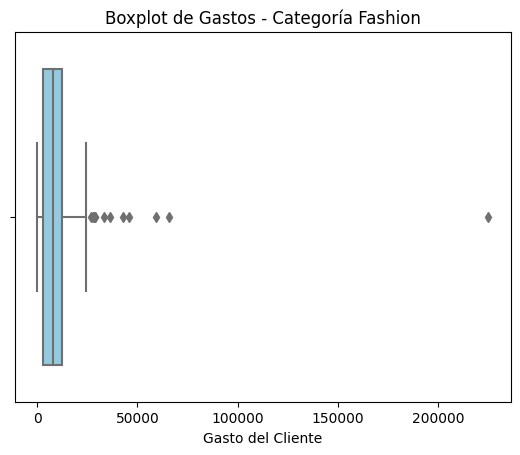

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/datasets/everpeak_clean.csv')
# Filtrar datos
df_fashion = df[df['product_category'] == 'Fashion']  
df_sports = df[df['product_category'] =='Sports'] 
# BoxPlot Categoría Fashion
sns.boxplot(x=df_fashion['order_value'], color='skyblue')  
plt.xlabel("Gasto del Cliente")  
plt.title("Boxplot de Gastos - Categoría Fashion")  
plt.show()

Identificando valores atípicos con reglas estadísticas

In [70]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("/datasets/everpeak_clean.csv").head(50)

In [71]:
#calcular Q1
Q1 = df['price'].quantile(0.25)
print('Primer cuartil: ', Q1)

Primer cuartil:  267.25


In [72]:
#calcular Q3
Q3 = df['price'].quantile(0.75)
print('Tercer cuartil: ', Q3)

Tercer cuartil:  580.0


In [73]:
#calcular IQR
IQR = Q3 - Q1
print('IQR: ', IQR)

IQR:  312.75


In [74]:
#calcular límite inferior
lower = Q1 - 1.5 * IQR
print('Límite inferior: ', lower)
#calcular límite superior
upper = Q3 + 1.5 * IQR
print('Límite superior: ', upper)

Límite inferior:  -201.875
Límite superior:  1049.125


In [ ]:
Obtenemos el IQR y detectamos valores atípicos:

Primer cuartil:  267.25
Tercer cuartil:  580.0
IQR:  312.75


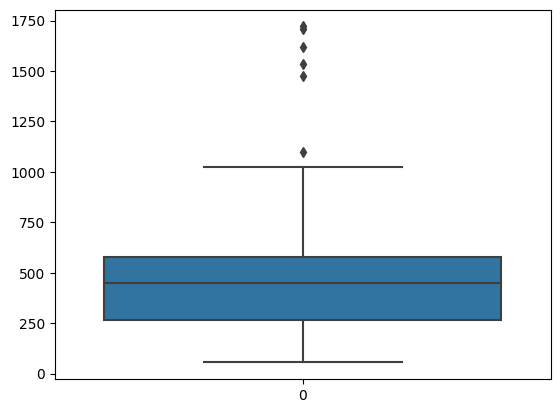

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("/datasets/everpeak_clean.csv").head(50)

#calcular Q1
Q1 = df['price'].quantile(0.25)
print('Primer cuartil: ', Q1)

#calcular Q3
Q3 = df['price'].quantile(0.75)
print('Tercer cuartil: ', Q3)

#calcular IQR
IQR = Q3 - Q1
print('IQR: ', IQR)
sns.boxplot(data=df['price'])
plt.show()

🎯 Objetivo: La gerencia de finanzas nos ha solicitado segmentar las transacciones según el método de pago y el volumen de compra, para analizar patrones de pago en compras altas y bajas.

In [79]:
import pandas as pd
df = pd.read_csv("/datasets/everpeak_retail.csv")
def classify_payment(row):
    card = row ["payment_method"]     
    qty = row ["quantity"]    
# 1. Manejo de valores nulos/faltantes
    if pd.isna(card) or pd.isna(qty):
        return "Error en Datos"
# --- 2. Segmentación de Altas Cantidades ---
    if qty > 22:
        if card == "credit_card" or card =="debit_card": 
            return "card_high_volume"
        else: 
            return "no_card_high_volume"
# --- 3. Segmentación Bajas Cantidades ---
    elif qty <= 22:
        if card == "credit_card" or card == "debit_card":   
            return "card_low_volume"     
        else: 
            return "no_card_low_volume"

# aplicar función y verificar cambios
df['payment_segment'] = df.apply(classify_payment, axis=1)  
print(df['payment_segment'].value_counts())

card_low_volume        2725
no_card_low_volume     1041
card_high_volume        909
no_card_high_volume     333
Name: payment_segment, dtype: int64


In [ ]:
📚Statistical Summary

In [ ]:
1. Calidad, Limpieza y Auditoría de los Datos

Integridad del Dataset: Se evaluó la estructura inicial del conjunto de datos everpeak_retail.csv, identificando y gestionando registros nulos o faltantes en variables críticas como el método de pago (payment_method) y la cantidad de artículos (quantity). Estos casos fueron aislados bajo la etiqueta "Error en Datos" para mantener la consistencia en el análisis posterior.

Tratamiento de Valores Atípicos (Outliers): Con el objetivo de evitar distorsiones en las métricas globales, se aplicaron los métodos estadísticos de Rango Intercuartílico (IQR) y Z-score sobre las variables de precio y volumen. Esto permitió identificar de manera precisa las transacciones inusualmente altas, asegurando que los promedios reflejen el comportamiento operativo estándar del negocio.

In [ ]:
2. Análisis Descriptivo y Segmentación

Comportamiento del Consumidor: Se implementó una función de segmentación para clasificar las transacciones según el volumen de compra. Se definió como "Alto Volumen" a los registros con más de 22 unidades por transacción, cruzando esta información con la modalidad de pago (tarjetas de crédito/débito frente a otros medios) para entender los hábitos de compra e identificar el perfil de los clientes mayoristas o de alta frecuencia.

istribución de Precios: Mediante el uso de histogramas, se analizó la simetría y dispersión de la variable price, contrastando la media y la mediana para determinar el sesgo en la distribución de ingresos por producto y establecer los rangos de precio con mayor rotación en el piso de venta.

In [ ]:
3. Eficiencia Operativa y Rendimiento Comercial

Productividad por Espacio: El análisis de las ventas por metro cuadrado reveló una marcada disparidad en la eficiencia de los departamentos. Las categorías de productos básicos (staples) y alimentos frescos demostraron un rendimiento sobresaliente en términos de rentabilidad por espacio asignado. Por el contrario, los departamentos de jardinería y artículos de oficina operan actualmente por debajo del promedio de eficiencia, lo que representa una oportunidad de reestructuración o reducción de superficie.

Distribución Regional: El desglose geográfico de los datos, enfocado en métricas como el volumen de productos colocados en la región Sur, permitió validar el peso de cada mercado en la facturación total y proporciona una base sólida para la planeación logística y la asignación de inventarios.